# Arbitrary electron distributions in VegasAfterglow

This notebook is a compact validation and usage guide for prescribing electron distributions in `VegasAfterglow` and computing their synchrotron emission and self-absorption (SSA).

The standard `main` VegasAfterglow implementation uses a fast Granot–Sari (GS02) smooth broken-power-law synchrotron spectrum. The `electron-distributions` development branch instead integrates the full single-electron synchrotron kernel over a supplied $dN/d\gamma$. The two treatments should recover the same characteristic scales and asymptotic behavior, while their detailed curvature near spectral breaks can differ.

For the public release, use `pip install vegasafterglow`. For the arbitrary-electron branch used here, install the `electron-distributions` branch from the `cjules0609/VegasAfterglow` fork with `pip install .` from the cloned source tree.

Run the notebook top-to-bottom. Edit the constants in §1 for routine experiments. Figures are saved to `./out/arbitrary_electron/`.


## 1. Setup

The first cell contains the baseline afterglow parameters and plotting ranges. Observer spectra are $F_\nu$ in $\mathrm{erg\,s^{-1}\,cm^{-2}\,Hz^{-1}}$; per-cell spectra are comoving specific intensities $I_{\nu'}$ in $\mathrm{erg\,s^{-1}\,cm^{-2}\,Hz^{-1}\,sr^{-1}}$.

Custom callables specify a shape proportional to $dN/d\gamma$ for total Lorentz factor $\gamma\ge1$. `normalization="energy"` scales that shape using the electron energy budget, while `normalization="number"` scales it using the participating electron number.


In [45]:
from itertools import permutations, product
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

from VegasAfterglow import (
    CutoffPowerLawElectrons,
    ElectronDistribution,
    FlatElectrons,
    ISM,
    Model,
    Observer,
    PowerLawElectrons,
    Radiation,
    TophatJet,
)

%matplotlib inline

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.alpha": 0.18,
    "lines.linewidth": 1.8,
    "legend.frameon": False,
})

FIGURE_DIR = Path("out/arbitrary_electron")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DPI = 220
FIGSIZE, WIDE_FIGSIZE, TRIPLE_FIGSIZE = (8, 5), (12, 5), (16, 5)

# Baseline afterglow configuration
E_ISO = 1e52
GAMMA0 = 100.0
THETA_C = 0.1
N_ISM = 1.0
LUMI_DIST = 1e28
REDSHIFT = 0.1
THETA_OBS = 0.0

P, EPS_E, EPS_B, XI_E = 2.3, 0.1, 1e-3, 1.0
T0 = 1e2
NU = np.logspace(7, 28, 280)
GAMMA_MIN, GAMMA_MAX = 1e2, 1e8
RESOLUTIONS = (0.1, 0.3, 8)

# 3e/(4 pi m_e c), matching the synchrotron-frequency convention in the backend.
SYN_FREQ_COEFF = 4.198e6  # Hz G^-1



In [46]:
def make_radiation(electrons=None, *, ssa=None, eps_e=EPS_E, eps_B=EPS_B,
                   p=P, xi_e=XI_E):
    kwargs = {} if ssa is None else {"ssa": ssa}
    return Radiation(
        eps_e=eps_e,
        eps_B=eps_B,
        p=p,
        xi_e=xi_e,
        electrons=electrons,
        **kwargs,
    )


def make_model(electrons=None, *, ssa=None, reverse=False, n_ism=N_ISM,
               E_iso=E_ISO, Gamma0=GAMMA0, eps_e=EPS_E, eps_B=EPS_B,
               p=P, xi_e=XI_E):
    rad = make_radiation(
        electrons,
        ssa=ssa,
        eps_e=eps_e,
        eps_B=eps_B,
        p=p,
        xi_e=xi_e,
    )
    return Model(
        jet=TophatJet(theta_c=THETA_C, E_iso=E_iso, Gamma0=Gamma0),
        medium=ISM(n_ism=n_ism),
        observer=Observer(
            lumi_dist=LUMI_DIST,
            z=REDSHIFT,
            theta_obs=THETA_OBS,
        ),
        fwd_rad=rad,
        rvs_rad=rad if reverse else None,
        resolutions=RESOLUTIONS,
    )


def custom_electrons(function, gamma_min=GAMMA_MIN, gamma_max=GAMMA_MAX,
                     normalization="energy", samples=64):
    return ElectronDistribution(
        function=function,
        gamma_min=gamma_min,
        gamma_max=gamma_max,
        normalization=normalization,
        samples_per_decade=samples,
    )


def observer_spectrum(model, frequency=NU, t_obs=T0, component="total"):
    result = model.flux_density_grid(
        np.atleast_1d(float(t_obs)),
        np.asarray(frequency, dtype=float),
    )
    values = result.total if component == "total" else getattr(result, component).sync
    return np.asarray(values)[:, 0]


def positive_xy(x, y):
    x, y = np.asarray(x), np.asarray(y)
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    return x[mask], y[mask]


def plot_positive(ax, x, y, *args, **kwargs):
    return ax.loglog(*positive_xy(x, y), *args, **kwargs)


def measured_slope(x, y):
    x, y = positive_xy(x, y)
    return np.polyfit(np.log(x), np.log(y), 1)[0]


def local_log_slope(x, y):
    x, y = positive_xy(x, y)
    return x, np.gradient(np.log(y), np.log(x))


def representative_cell(shock):
    B = np.asarray(shock.B_comv, dtype=float)
    score = np.where(np.isfinite(B) & (B > 0), B, -np.inf)
    return tuple(map(int, np.unravel_index(np.argmax(score), score.shape)))


def nearest_index(values, target):
    return int(np.argmin(np.abs(np.asarray(values) - target)))


def selected_cell(details, t_obs=T0, i=0, j=0):
    k = nearest_index(details.fwd.t_obs[i, j, :], t_obs)
    return i, j, k


def tau_one_frequency(frequency, optical_depth):
    """Highest-frequency crossing of tau_nu = 1."""
    frequency = np.asarray(frequency, dtype=float)
    tau = np.asarray(optical_depth, dtype=float)
    if not np.all(np.isfinite(frequency)):
        raise ValueError("frequency grid contains non-finite values")

    log_tau = np.log(np.clip(tau, np.finfo(float).tiny, None))
    crossings = np.flatnonzero((log_tau[:-1] >= 0) & (log_tau[1:] <= 0))
    if not crossings.size:
        raise ValueError("frequency grid does not bracket tau_nu = 1")

    k = crossings[-1]
    return np.exp(np.interp(
        0.0,
        log_tau[k:k + 2][::-1],
        np.log(frequency[k:k + 2])[::-1],
    ))


def transfer_factor(tau):
    """Stable evaluation of (1 - exp(-tau)) / tau."""
    tau = np.asarray(tau, dtype=float)
    out = np.empty_like(tau)
    finite = tau > 1e-8
    out[finite] = -np.expm1(-tau[finite]) / tau[finite]
    out[~finite] = 1 - tau[~finite] / 2 + tau[~finite] ** 2 / 6
    return out


def standard_electron_shape(gamma_m, gamma_c, gamma_max, p):
    """Mirror the smooth standard electron shape used for electron-space integrations."""
    def shape(gamma):
        gamma = np.asarray(gamma, dtype=float)
        cutoff = np.exp(-gamma / gamma_max)
        if gamma_m <= gamma_c:  # slow cooling
            return (
                (p - 1) / gamma_m
                * cutoff
                * np.exp(-gamma_m / gamma)
                * (gamma / gamma_m) ** (-p)
                * gamma_c / (gamma + gamma_c)
            )
        return (
            cutoff
            * np.exp(-gamma_c / gamma)
            * gamma_c / gamma**2
            / (1 + (gamma / gamma_m) ** (p - 1))
        )
    return shape


def maxwell_juttner_shape(gamma, theta):
    """Unnormalized Maxwell-Juttner dN/dgamma; theta = kT/(m_e c^2)."""
    gamma = np.asarray(gamma, dtype=float)
    beta = np.sqrt(np.maximum(1.0 - gamma**-2, 0.0))
    return gamma**2 * beta * np.exp(-gamma / theta)


def lognormal_shape(gamma, gamma0, sigma):
    gamma = np.asarray(gamma, dtype=float)
    return np.exp(-0.5 * (np.log(gamma / gamma0) / sigma) ** 2)


def input_shape(electrons, points=500):
    if isinstance(electrons, ElectronDistribution):
        return np.asarray(electrons.gamma), np.asarray(electrons.shape)

    gamma = np.logspace(
        np.log10(electrons.gamma_min),
        np.log10(electrons.gamma_max),
        points,
    )
    if isinstance(electrons, FlatElectrons):
        shape = np.ones_like(gamma)
    elif isinstance(electrons, CutoffPowerLawElectrons):
        shape = gamma ** (-electrons.p) * np.exp(-gamma / electrons.gamma_cut)
    elif isinstance(electrons, PowerLawElectrons):
        shape = gamma ** (-electrons.p)
    else:
        raise TypeError(f"Unsupported electron object: {type(electrons)!r}")
    return gamma, shape


def normalized_for_plot(values):
    values = np.asarray(values, dtype=float)
    maximum = np.nanmax(values)
    return values / maximum if maximum > 0 else values


def spectrum_axes(ax, title=None, xlim=None, ylim=None):
    kwargs = {"xlabel": "Observer frequency [Hz]", "ylabel": r"$F_\nu$ [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]"}
    if title is not None:
        kwargs["title"] = title
    if xlim is not None:
        kwargs["xlim"] = xlim
    if ylim is not None:
        kwargs["ylim"] = ylim
    ax.set(**kwargs)


def show_figure(fig, filename):
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"{filename}.png", dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()
    plt.close(fig)


## 2. Standard reference and numerical validation

The standard model provides the GS02 observer spectrum. The matched-cell tests then compare that fitted photon spectrum with the full numerical synchrotron convolution using the same local electron shape and cell properties.


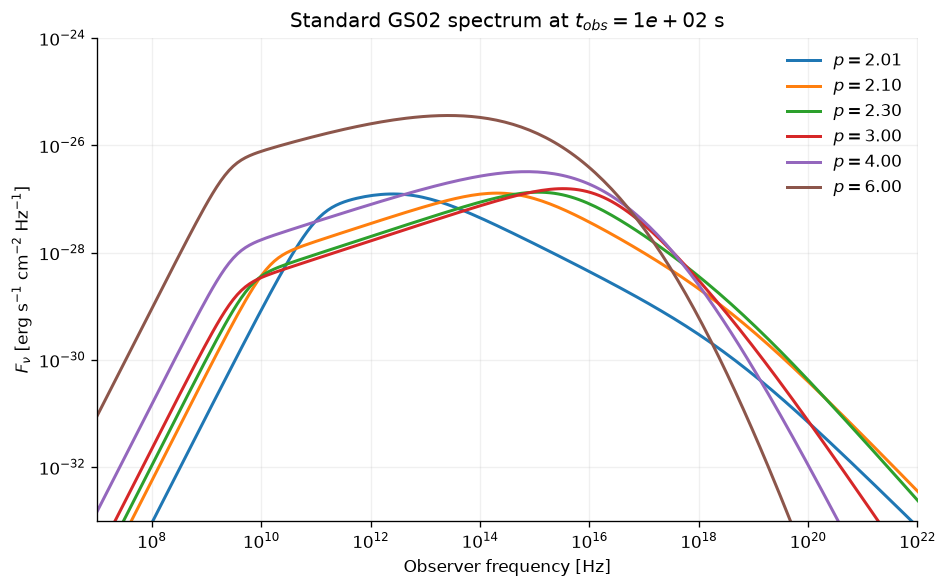

In [47]:
p_values = [2.01, 2.1, 2.3, 3.0, 4.0, 6.0]

fig, ax = plt.subplots(figsize=FIGSIZE)
for p in p_values:
    plot_positive(ax, NU, observer_spectrum(make_model(p=p)), label=fr"$p={p:.2f}$")

spectrum_axes(
    ax,
    title=fr"Standard GS02 spectrum at $t_{{obs}}={T0:.0e}$ s",
    xlim=(1e7, 1e22),
    ylim=(1e-33, 1e-24),
)
ax.legend()
show_figure(fig, "02_standard_reference")


### 2.1 Matched-cell GS02 versus full-kernel spectrum

The standard and numerical calculations use the same selected cell and the same smooth standard electron distribution. GS02 fits the photon spectrum with smoothed asymptotic segments; the numerical branch directly evaluates the synchrotron kernel. They should therefore agree on asymptotic behavior and characteristic scales, but not necessarily on the exact curvature or peak location near $\nu_m$.

Here $\nu_m=\nu(\gamma_m)$ is a characteristic frequency, not a definition of the spectral maximum.


slow cooling | nu_a(num)/nu_a(GS02)=1.009 | nu_peak/nu_m: GS02=0.463, numerical=0.116


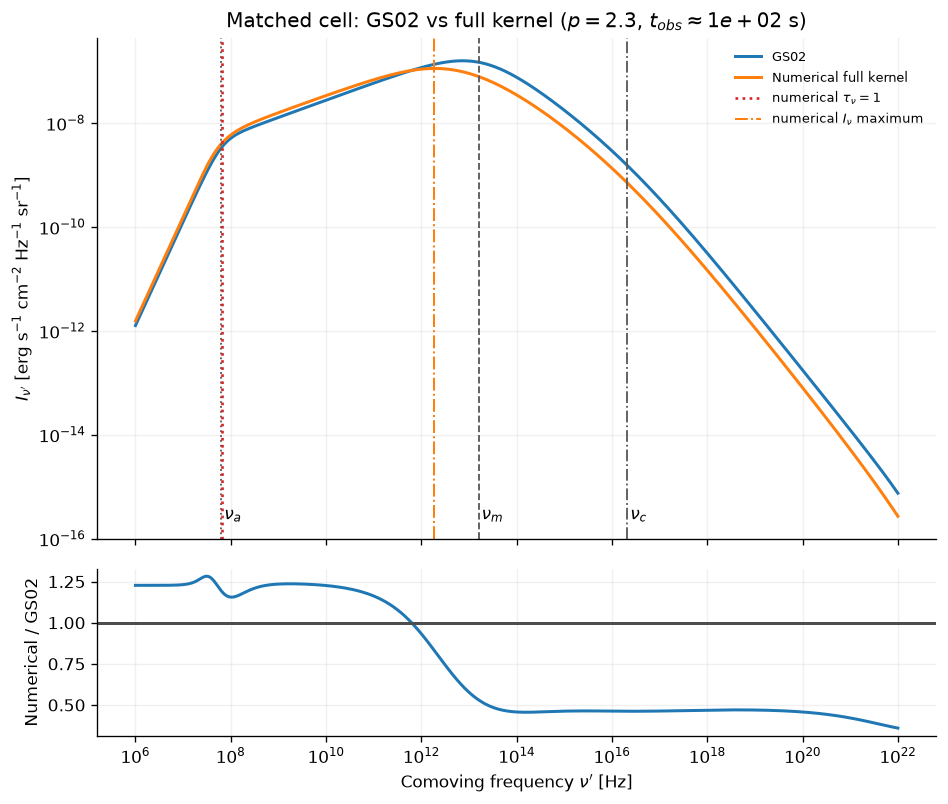

In [48]:
p = P
standard_model = make_model(p=p)
standard_details = standard_model.details(t_min=T0 / 10, t_max=T0 * 10)
std_idx = selected_cell(standard_details)

gamma_m = float(standard_details.fwd.gamma_m[std_idx])
gamma_c = float(standard_details.fwd.gamma_c[std_idx])
gamma_M = float(standard_details.fwd.gamma_M[std_idx])
nu_a = float(standard_details.fwd.nu_a[std_idx])
nu_m = float(standard_details.fwd.nu_m[std_idx])
nu_c = float(standard_details.fwd.nu_c[std_idx])

electrons = custom_electrons(
    standard_electron_shape(gamma_m, gamma_c, gamma_M, p),
    gamma_min=1.0,
    gamma_max=gamma_M,
    normalization="number",
)
numerical_model = make_model(electrons, ssa=True, p=p)
numerical_details = numerical_model.details(t_min=T0 / 10, t_max=T0 * 10)
num_idx = selected_cell(numerical_details)

nu_comoving = np.logspace(6, 22, 800)
I_std = np.asarray(standard_details.fwd.sync_spectrum[std_idx](nu_comoving))
I_num = np.asarray(numerical_details.fwd.sync_spectrum[num_idx](nu_comoving))
tau_num = np.asarray(numerical_details.fwd.sync_optical_depth[num_idx](nu_comoving))

nu_a_num = tau_one_frequency(nu_comoving, tau_num)
nu_peak_std = nu_comoving[np.nanargmax(I_std)]
nu_peak_num = nu_comoving[np.nanargmax(I_num)]

regime = "slow" if gamma_m <= gamma_c else "fast"
print(
    f"{regime} cooling | nu_a(num)/nu_a(GS02)={nu_a_num / nu_a:.3f} | "
    f"nu_peak/nu_m: GS02={nu_peak_std / nu_m:.3f}, "
    f"numerical={nu_peak_num / nu_m:.3f}"
)

valid = np.isfinite(I_std) & np.isfinite(I_num) & (I_std > 0) & (I_num > 0)

fig, axes = plt.subplots(
    2, 1, figsize=(8, 6.8), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

plot_positive(axes[0], nu_comoving, I_std, label="GS02")
plot_positive(axes[0], nu_comoving, I_num, label="Numerical full kernel")
for label, frequency, ls in (
    (r"$\nu_a$", nu_a, ":"),
    (r"$\nu_m$", nu_m, "--"),
    (r"$\nu_c$", nu_c, "-."),
):
    axes[0].axvline(frequency, color="0.35", ls=ls, lw=1.1)
    axes[0].text(
        frequency * 1.15, 0.03, label,
        transform=axes[0].get_xaxis_transform(), va="bottom",
    )
axes[0].axvline(
    nu_a_num, color="C3", ls=":", lw=1.6, label=r"numerical $\tau_\nu=1$"
)
axes[0].axvline(
    nu_peak_num, color="C1", ls="-.", lw=1.2, label=r"numerical $I_\nu$ maximum"
)
axes[0].set(
    ylabel=r"$I_{\nu'}$ [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$ sr$^{-1}$]",
    title=rf"Matched cell: GS02 vs full kernel ($p={p}$, $t_{{obs}}\approx{T0:.0e}$ s)",
)
axes[0].legend(fontsize=8)

axes[1].semilogx(nu_comoving[valid], I_num[valid] / I_std[valid])
axes[1].axhline(1, color="0.3")
axes[1].set(
    xlabel=r"Comoving frequency $\nu'$ [Hz]",
    ylabel="Numerical / GS02",
)
show_figure(fig, "02_matched_cell_gs02_vs_numerical")


### 2.2 Per-cell coverage of break orderings

This optional diagnostic searches the standard model for one physically realized cell in each ordering of $\nu_a$, $\nu_m$, and $\nu_c$. Each panel compares the standard and numerical **comoving cell spectrum** for that state. Using per-cell spectra is important here: an observer-integrated spectrum mixes many cells and does not have a unique local break ordering.

This is the slowest cell in the notebook and can be skipped for routine use.


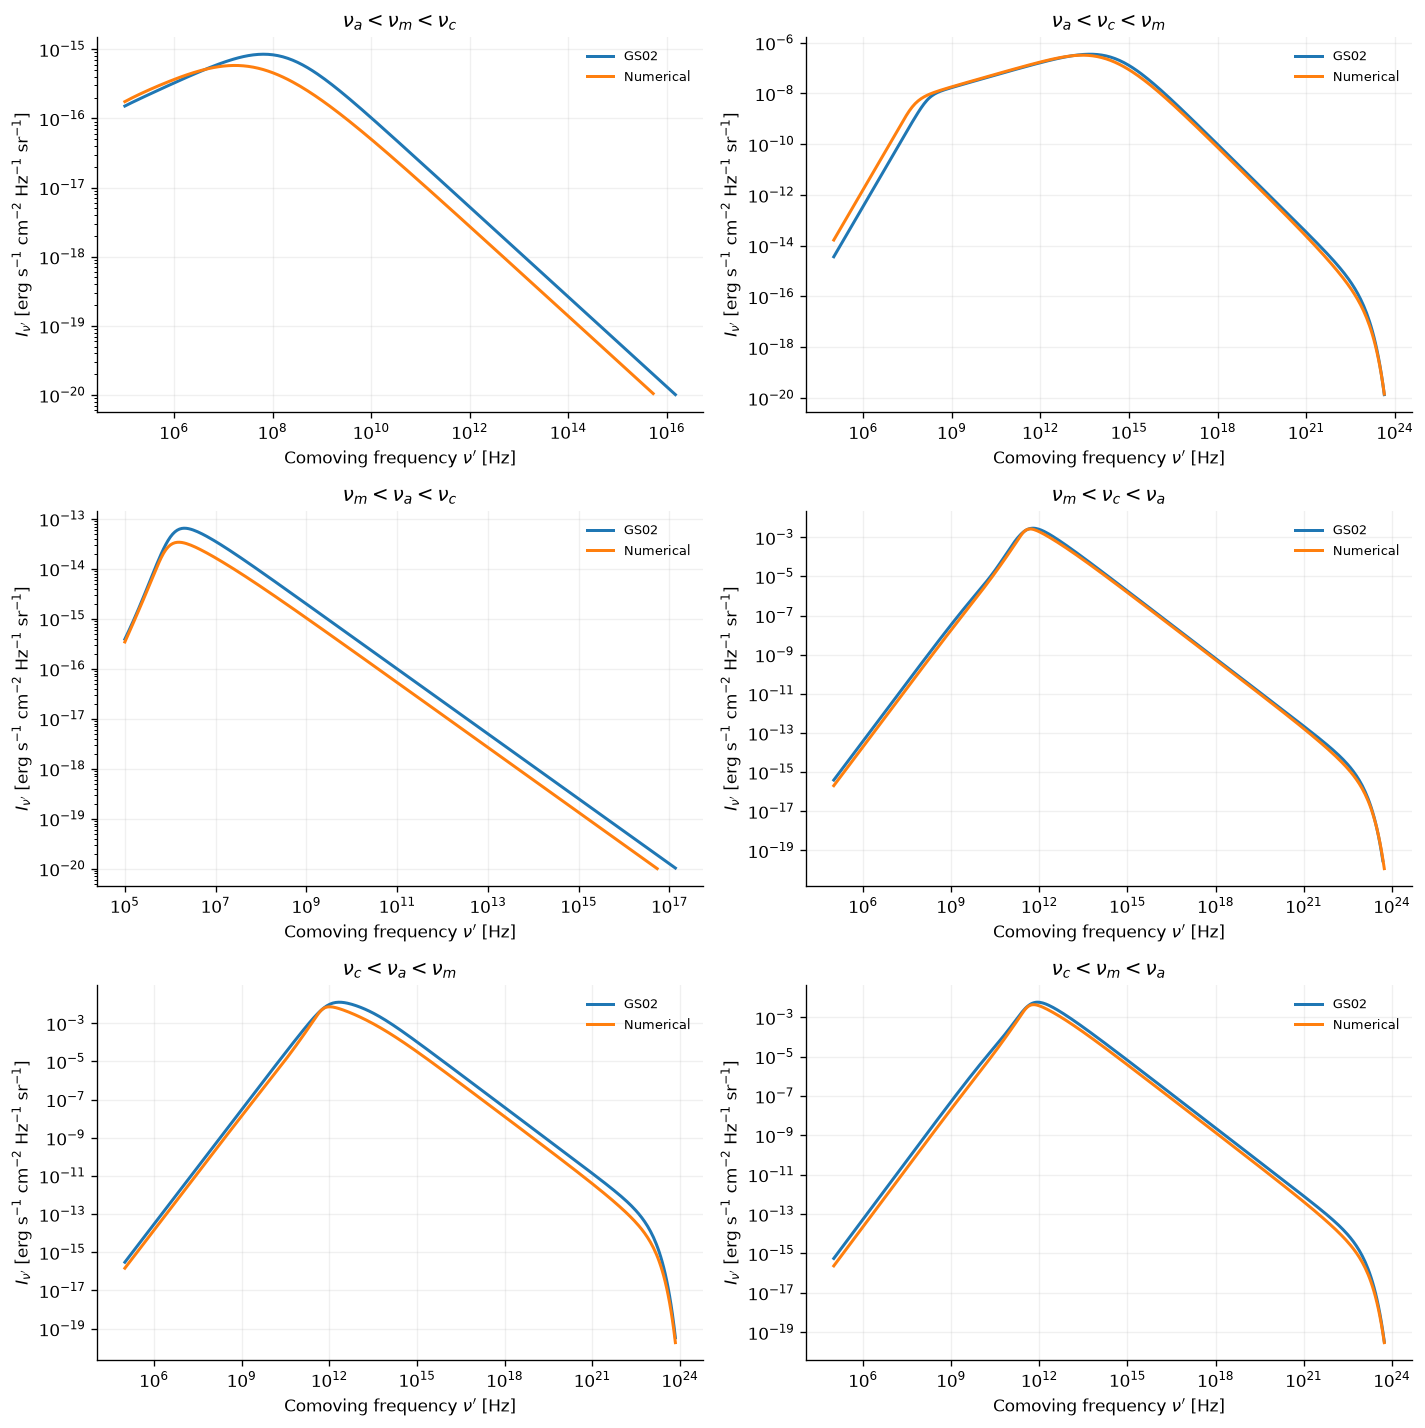

In [49]:
ORDERING_FREQUENCY = np.logspace(5, 25, 400)
ORDERING_TIMES = np.logspace(1, 8, 36)
TARGET_ORDERINGS = tuple(permutations("amc"))


def break_ordering(details, idx):
    breaks = {x: float(getattr(details.fwd, f"nu_{x}")[idx]) for x in "amc"}
    if not all(np.isfinite(v) and v > 0 for v in breaks.values()):
        return None
    return tuple(sorted(breaks, key=breaks.get))


cases = {}
parameter_grid = product(
    (1e-4, 1e-2, 1.0, 1e2, 1e4),  # n_ism
    (1e-6, 1e-4, 1e-2, 1e-1),      # eps_B
    (0.01, 0.1, 0.3),               # eps_e
)

for n_ism, eps_B, eps_e in parameter_grid:
    model = make_model(n_ism=n_ism, eps_B=eps_B, eps_e=eps_e)
    details = model.details(
        t_min=ORDERING_TIMES[0] / 3,
        t_max=ORDERING_TIMES[-1] * 3,
    )
    times = np.asarray(details.fwd.t_obs[0, 0])

    for requested_time in ORDERING_TIMES:
        idx = (0, 0, nearest_index(times, requested_time))
        ordering = break_ordering(details, idx)
        if ordering is None or ordering in cases:
            continue
        cases[ordering] = {
            "details": details,
            "idx": idx,
            "t_obs": float(times[idx[-1]]),
            "n_ism": n_ism,
            "eps_B": eps_B,
            "eps_e": eps_e,
        }

    if len(cases) == len(TARGET_ORDERINGS):
        break

missing = [o for o in TARGET_ORDERINGS if o not in cases]
if missing:
    print("Missing:", ", ".join(" < ".join(f"nu_{x}" for x in o) for o in missing))

for case in cases.values():
    details, idx = case["details"], case["idx"]
    gm = float(details.fwd.gamma_m[idx])
    gc = float(details.fwd.gamma_c[idx])
    gM = float(details.fwd.gamma_M[idx])

    electrons = custom_electrons(
        standard_electron_shape(gm, gc, gM, P),
        gamma_min=1.0,
        gamma_max=gM,
        normalization="number",
    )
    numerical_model = make_model(
        electrons,
        ssa=True,
        n_ism=case["n_ism"],
        eps_e=case["eps_e"],
        eps_B=case["eps_B"],
    )
    numerical_details = numerical_model.details(
        t_min=ORDERING_TIMES[0] / 3,
        t_max=ORDERING_TIMES[-1] * 3,
    )
    num_idx = selected_cell(numerical_details, t_obs=case["t_obs"])

    case["I_std"] = np.asarray(
        details.fwd.sync_spectrum[idx](ORDERING_FREQUENCY)
    )
    case["I_num"] = np.asarray(
        numerical_details.fwd.sync_spectrum[num_idx](ORDERING_FREQUENCY)
    )

ordered_cases = [o for o in TARGET_ORDERINGS if o in cases]
ncols = 2
nrows = int(np.ceil(len(ordered_cases) / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(12, 4.0 * nrows),
    squeeze=False,
)

I_MIN = 1e-20

for ax, ordering in zip(axes.flat, ordered_cases):
    case = cases[ordering]

    I_std_plot = np.where(case["I_std"] >= I_MIN, case["I_std"], np.nan)
    I_num_plot = np.where(case["I_num"] >= I_MIN, case["I_num"], np.nan)

    plot_positive(
        ax, ORDERING_FREQUENCY, I_std_plot,
        label="GS02",
    )
    plot_positive(
        ax, ORDERING_FREQUENCY, I_num_plot,
        label="Numerical",
    )

    label = " < ".join(rf"\nu_{x}" for x in ordering)

    ax.set(
        xlabel=r"Comoving frequency $\nu'$ [Hz]",
        ylabel=r"$I_{\nu'}$ [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$ sr$^{-1}$]",
        title=rf"${label}$",
    )
    ax.legend(fontsize=8)

for ax in axes.flat[len(ordered_cases):]:
    ax.set_visible(False)

show_figure(fig, "02_break_orderings")

## 3. Synchrotron self-absorption

SSA is computed from the numerical absorption coefficient. For a homogeneous cell,

$$
\frac{I_\nu}{I_{\nu,\mathrm{thin}}}
=\frac{1-e^{-\tau_\nu}}{\tau_\nu}.
$$

The first test checks this transfer relation directly; the following diagnostics examine optically thick asymptotes and non-power-law electron populations.


SSA transfer max relative error = 9.992e-15


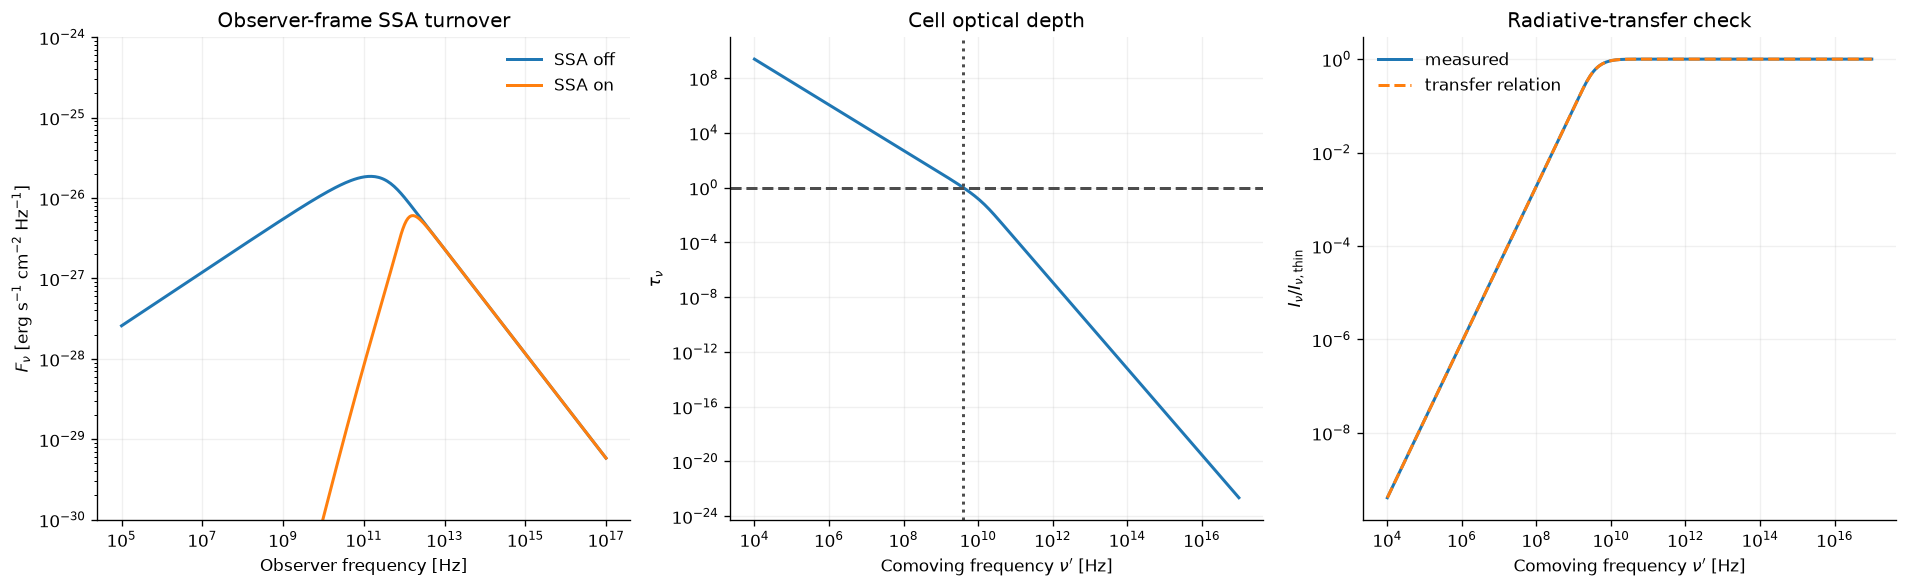

In [50]:
ssa_e = PowerLawElectrons(
    p=P, gamma_min=10, gamma_max=1e8, normalization="number"
)
ssa_models = {
    state: make_model(ssa_e, ssa=enabled, eps_B=1e-2, n_ism=10)
    for state, enabled in {"off": False, "on": True}.items()
}

nu_ssa_obs = np.logspace(5, 17, 280)
ssa_flux = {
    state: observer_spectrum(model, nu_ssa_obs)
    for state, model in ssa_models.items()
}

details = {state: model.details(1e2, 1e6) for state, model in ssa_models.items()}
idx_ssa = representative_cell(details["on"].fwd)

nu_comv = np.logspace(4, 17, 300)
tau_ssa = np.asarray(details["on"].fwd.sync_optical_depth[idx_ssa](nu_comv))
I_ssa = np.asarray(details["on"].fwd.sync_spectrum[idx_ssa](nu_comv))
I_thin = np.asarray(details["off"].fwd.sync_spectrum[idx_ssa](nu_comv))
valid = (
    np.isfinite(I_ssa) & np.isfinite(I_thin) & np.isfinite(tau_ssa)
    & (I_ssa > 0) & (I_thin > 0) & (tau_ssa >= 0)
)
measured = I_ssa[valid] / I_thin[valid]
expected = transfer_factor(tau_ssa[valid])
nu_a_cell = tau_one_frequency(nu_comv, tau_ssa)
transfer_error = np.max(np.abs(measured / expected - 1))

print(f"SSA transfer max relative error = {transfer_error:.3e}")

fig, axes = plt.subplots(1, 3, figsize=TRIPLE_FIGSIZE)
for state in ("off", "on"):
    plot_positive(axes[0], nu_ssa_obs, ssa_flux[state], label=f"SSA {state}")
spectrum_axes(axes[0], "Observer-frame SSA turnover")
axes[0].set_ylim(1e-30, 1e-24)
axes[0].legend()

plot_positive(axes[1], nu_comv, tau_ssa)
axes[1].axhline(1, color="0.3", ls="--")
axes[1].axvline(nu_a_cell, color="0.3", ls=":")
axes[1].set(
    xlabel=r"Comoving frequency $\nu'$ [Hz]",
    ylabel=r"$\tau_\nu$",
    title="Cell optical depth",
)

axes[2].loglog(nu_comv[valid], measured, label="measured")
axes[2].loglog(nu_comv[valid], expected, ls="--", label="transfer relation")
axes[2].set(
    xlabel=r"Comoving frequency $\nu'$ [Hz]",
    ylabel=r"$I_\nu/I_{\nu,\rm thin}$",
    title="Radiative-transfer check",
)
axes[2].legend()
show_figure(fig, "03_ssa_transfer")


### 3.1 SSA for non-power-law electrons

The same absorption integral works for arbitrary shapes. These examples compare SSA off/on for a flat distribution, a Maxwell–Jüttner population, and a pile-up distribution; no analytic break frequencies are imposed.


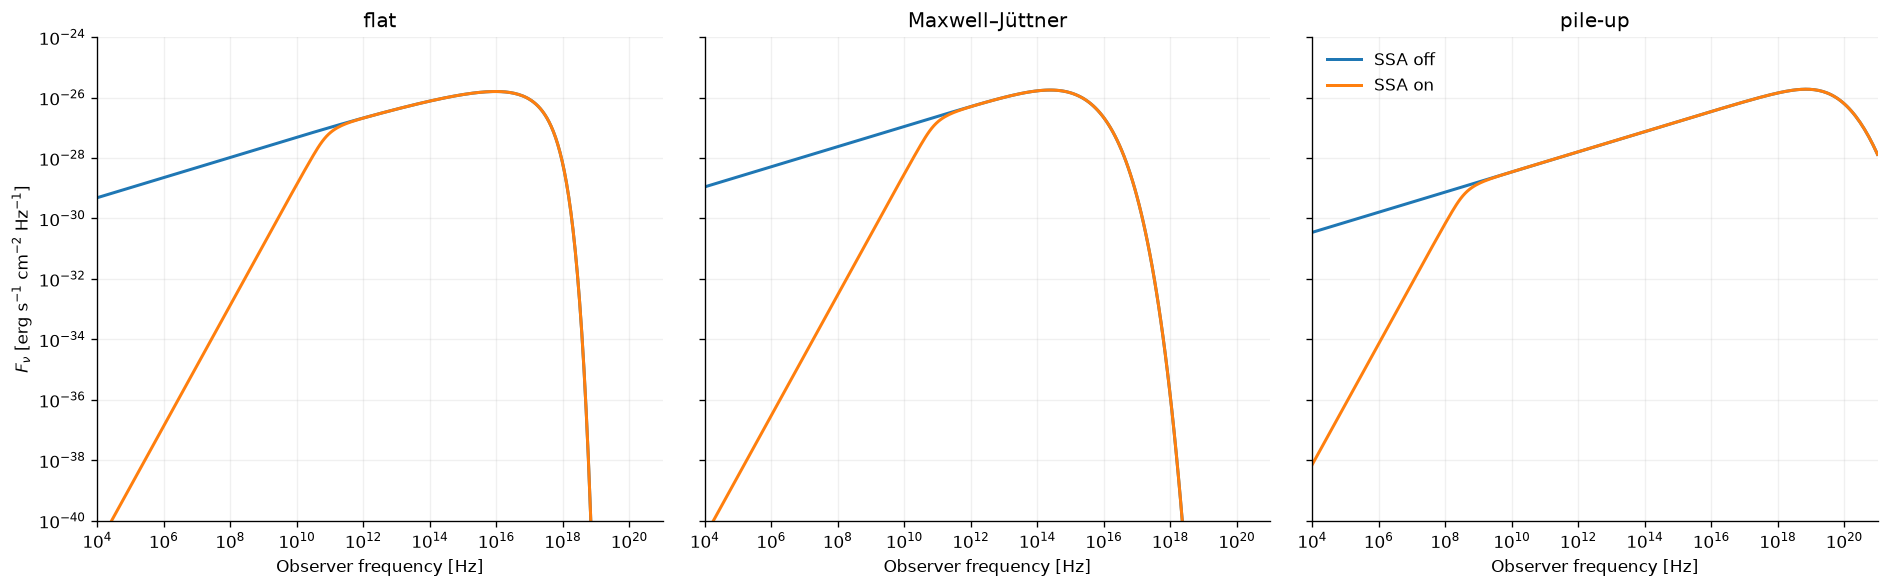

In [64]:
SSA_THETA = 300.0
SSA_PILE_GAMMA0 = 1e5

def ssa_maxwell_juttner(gamma):
    return maxwell_juttner_shape(gamma)


def ssa_pileup(gamma):
    return lognormal_shape(gamma, SSA_PILE_GAMMA0, 0.5)


ssa_nonpower = {
    "flat": FlatElectrons(
        gamma_min=10,
        gamma_max=1e4,
        normalization="number",
    ),

    "Maxwell–Jüttner": custom_electrons(
        ssa_maxwell_juttner,
        gamma_min=1.001,
        gamma_max=1e5,
        normalization="number",
    ),

    "pile-up": custom_electrons(
        ssa_pileup,
        gamma_min=10,
        gamma_max=1e7,
        normalization="number",
    ),
}
nu_nonpower = np.logspace(4, 21, 260)

fig, axes = plt.subplots(1, 3, figsize=TRIPLE_FIGSIZE, sharey=True)
for ax, (name, electrons) in zip(axes, ssa_nonpower.items()):
    for label, ssa in (("SSA off", False), ("SSA on", True)):
        flux = observer_spectrum(
            make_model(electrons, ssa=ssa, eps_B=1e-2, n_ism=10),
            nu_nonpower,
        )
        plot_positive(ax, nu_nonpower, flux, label=label)
    ax.set(
        xlabel="Observer frequency [Hz]",
        title=name,
        xlim=(1e4, 1e21),
        ylim=(1e-40, 1e-24),
    )

axes[0].set_ylabel(r"$F_\nu$ [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
axes[-1].legend()
show_figure(fig, "03_ssa_nonpower")


## 4. Built-in electron distributions

The numerical API provides bounded flat, power-law, and exponentially cut off power-law distributions. These examples are optically thin so the effect of the input electron shape is easy to isolate.


### 4.1 Bounded power law

A bounded, energy-normalized power law provides the simplest numerical reference.


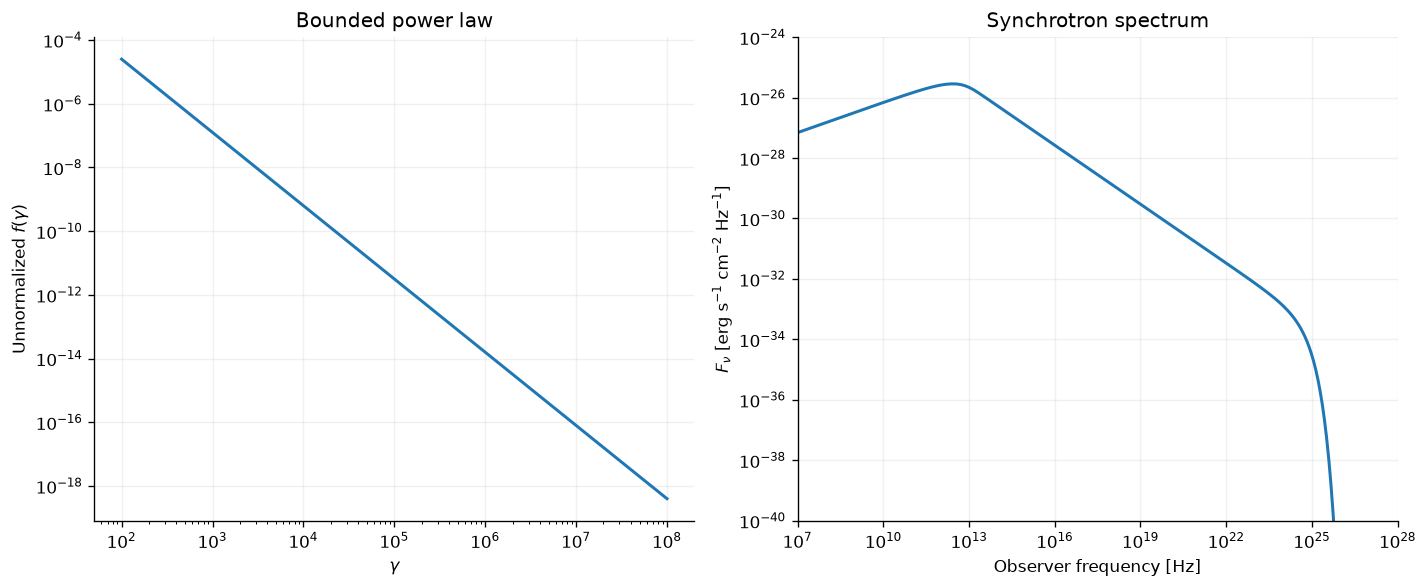

In [52]:
power_e = PowerLawElectrons(
    p=P,
    gamma_min=GAMMA_MIN,
    gamma_max=GAMMA_MAX,
    normalization="energy",
)
power_flux = observer_spectrum(make_model(power_e, ssa=False))
g_power, f_power = input_shape(power_e)

fig, axes = plt.subplots(1, 2, figsize=WIDE_FIGSIZE)
plot_positive(axes[0], g_power, f_power)
axes[0].set(
    xlabel=r"$\gamma$",
    ylabel=r"Unnormalized $f(\gamma)$",
    title="Bounded power law",
)
plot_positive(axes[1], NU, power_flux)
spectrum_axes(
    axes[1],
    "Synchrotron spectrum",
    xlim=(1e7, 1e28),
    ylim=(1e-40, 1e-24),
)
show_figure(fig, "04_bounded_powerlaw")


### 4.2 Flat distribution

A flat $dN/d\gamma$ is a useful non-power-law sanity check. Standard quantities such as $\gamma_m$, $\gamma_c$, $\nu_m$, and $\nu_c$ are not required for arbitrary distributions; the spectrum is computed directly from the supplied shape.


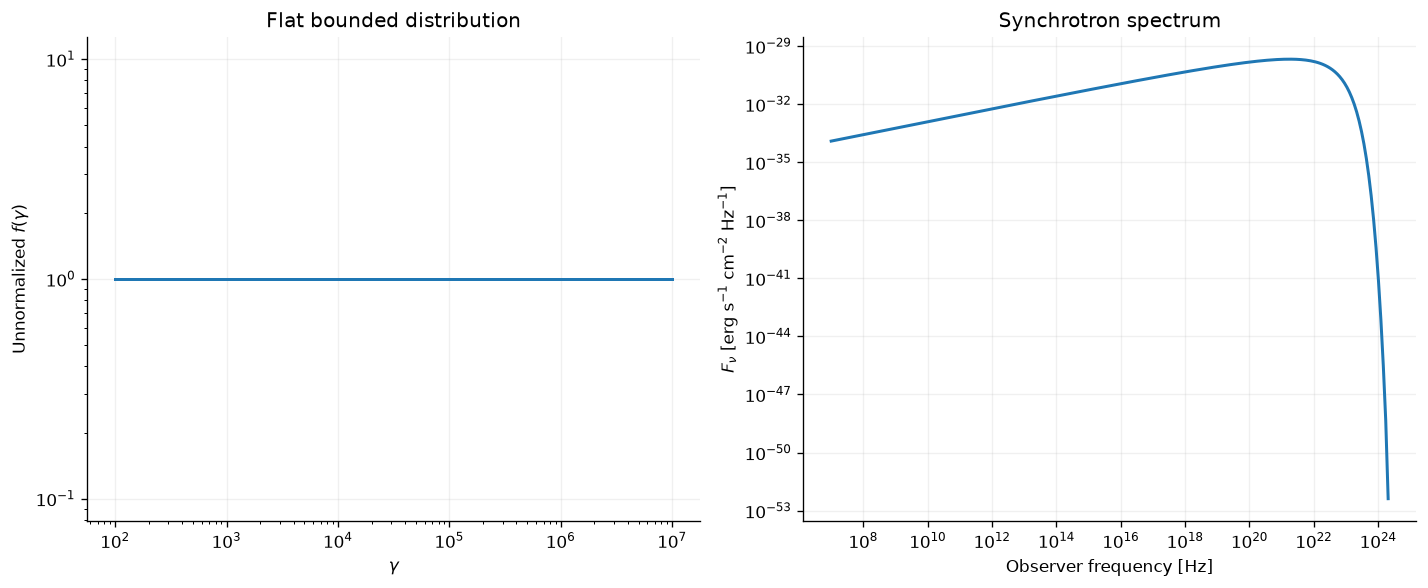

In [53]:
flat_e = FlatElectrons(
    gamma_min=1e2,
    gamma_max=1e7,
    normalization="energy",
)
flat_flux = observer_spectrum(make_model(flat_e, ssa=False))
g_flat, f_flat = input_shape(flat_e)

fig, axes = plt.subplots(1, 2, figsize=WIDE_FIGSIZE)
plot_positive(axes[0], g_flat, f_flat)
axes[0].set(
    xlabel=r"$\gamma$",
    ylabel=r"Unnormalized $f(\gamma)$",
    title="Flat bounded distribution",
)
plot_positive(axes[1], NU, flat_flux)
spectrum_axes(axes[1], "Synchrotron spectrum")
show_figure(fig, "04_flat")


### 4.3 Cutoff power law

An exponential cutoff in electron energy produces a smooth high-frequency suppression in the synchrotron spectrum.


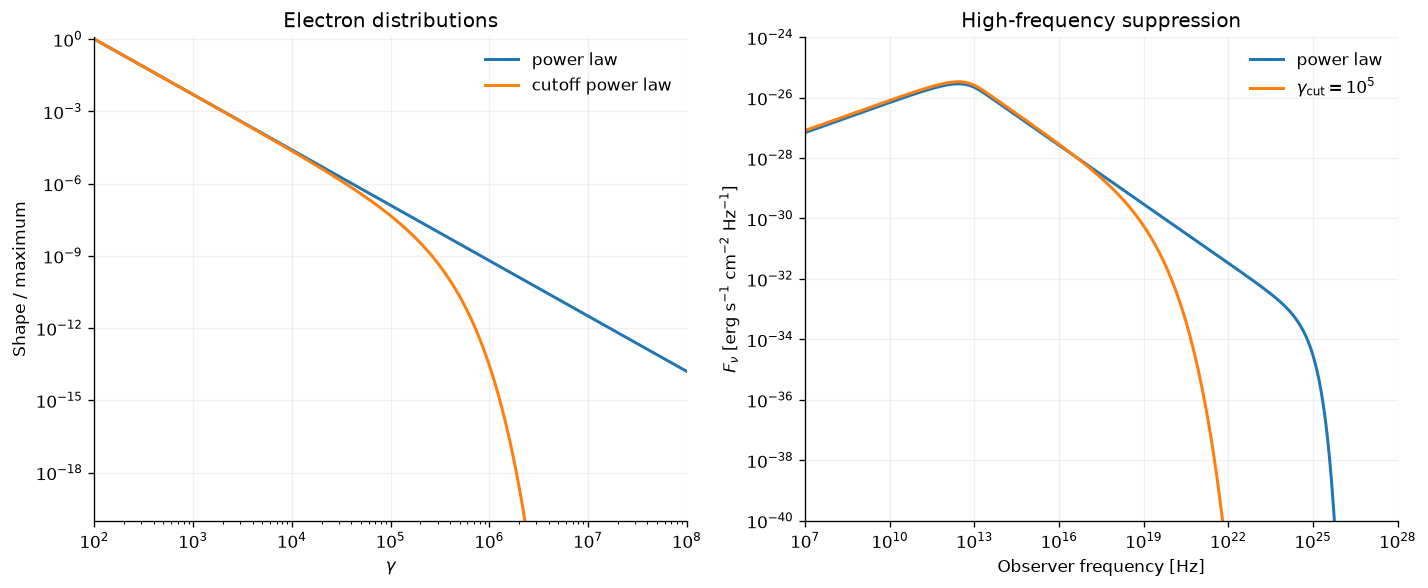

In [54]:
cutoff_e = CutoffPowerLawElectrons(
    p=P,
    gamma_min=GAMMA_MIN,
    gamma_max=GAMMA_MAX,
    gamma_cut=1e5,
    normalization="energy",
)
cutoff_flux = observer_spectrum(make_model(cutoff_e, ssa=False))
g_cut, f_cut = input_shape(cutoff_e)

fig, axes = plt.subplots(1, 2, figsize=WIDE_FIGSIZE)
plot_positive(axes[0], g_power, normalized_for_plot(f_power), label="power law")
plot_positive(axes[0], g_cut, normalized_for_plot(f_cut), label="cutoff power law")
axes[0].set(
    xlabel=r"$\gamma$",
    ylabel="Shape / maximum",
    title="Electron distributions",
    xlim=(1e2, 1e8),
    ylim=(1e-20, 1.2),
)
axes[0].legend()

plot_positive(axes[1], NU, power_flux, label="power law")
plot_positive(axes[1], NU, cutoff_flux, label=r"$\gamma_{\rm cut}=10^5$")
spectrum_axes(
    axes[1],
    "High-frequency suppression",
    xlim=(1e7, 1e28),
    ylim=(1e-40, 1e-24),
)
axes[1].legend()
show_figure(fig, "04_cutoff_powerlaw")


## 5. Number versus energy normalization

Normalization sets the physical scale of the same prescribed shape. Energy normalization targets the electron energy budget through $\epsilon_e$; number normalization targets the participating electron fraction through $\xi_e$. A fixed shape and $\gamma$ range generally cannot satisfy both constraints exactly at the same time.


energy: number fraction=0.1850, energy fraction=0.0700
number: number fraction=0.2000, energy fraction=0.0757


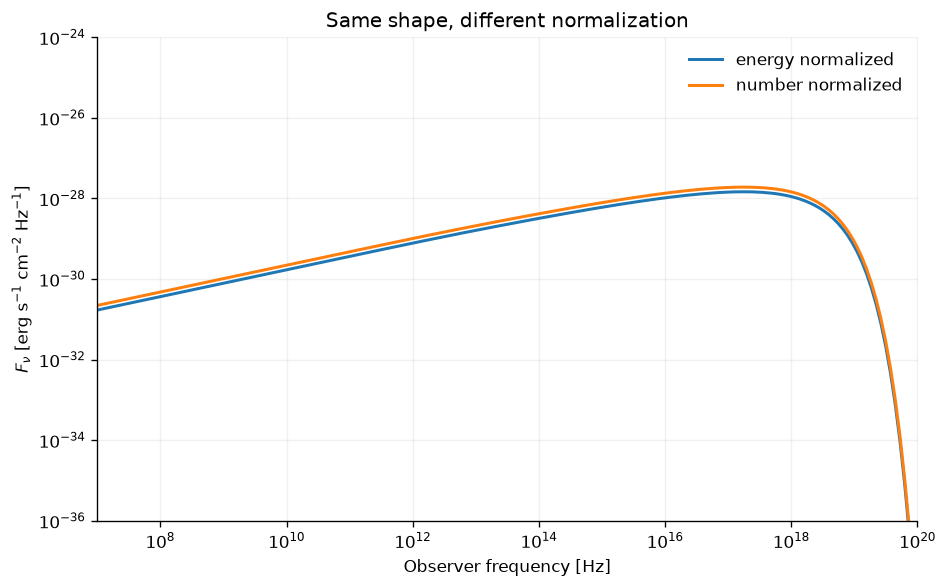

In [55]:
normalizations = {
    mode: FlatElectrons(gamma_min=1e2, gamma_max=1e5, normalization=mode)
    for mode in ("energy", "number")
}
models = {
    mode: make_model(electrons, ssa=False, eps_e=0.07, xi_e=0.2)
    for mode, electrons in normalizations.items()
}
fluxes = {mode: observer_spectrum(model) for mode, model in models.items()}
details = {mode: model.details(1e3, 1e6) for mode, model in models.items()}
idx = representative_cell(details["energy"].fwd)

for mode in ("energy", "number"):
    shock = details[mode].fwd
    print(
        f"{mode:6s}: number fraction={shock.electron_number_fraction[idx]:.4f}, "
        f"energy fraction={shock.electron_energy_fraction[idx]:.4f}"
    )

fig, ax = plt.subplots(figsize=FIGSIZE)
for mode in ("energy", "number"):
    plot_positive(ax, NU, fluxes[mode], label=f"{mode} normalized")
spectrum_axes(
    ax,
    "Same shape, different normalization",
    xlim=(1e7, 1e20),
    ylim=(1e-36, 1e-24),
)
ax.legend()
show_figure(fig, "05_normalization")


## 6. Custom callable API

A Python callable can reproduce a built-in electron shape. Agreement is expected over the well-resolved interior of the spectrum; small differences near the imposed $\gamma$ boundaries can arise from discrete sampling and interpolation of the callable distribution.


max relative difference in resolved band = 1.920e-06


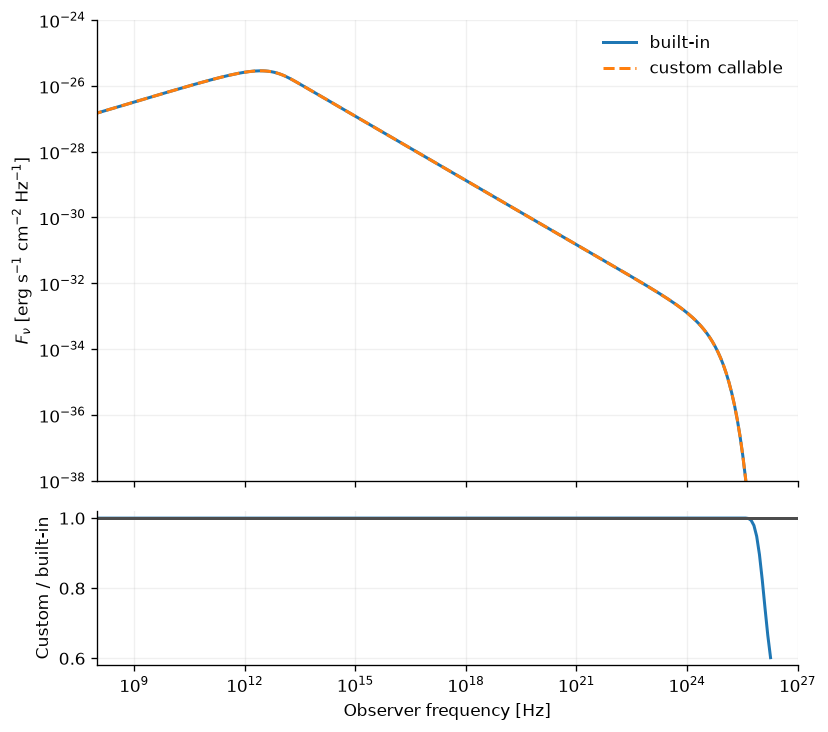

In [56]:
def custom_powerlaw(gamma):
    return gamma ** (-P)


custom_power_e = custom_electrons(custom_powerlaw)
custom_power_flux = observer_spectrum(make_model(custom_power_e, ssa=False))

valid = np.isfinite(power_flux) & np.isfinite(custom_power_flux) & (power_flux > 0)
resolved = valid & (power_flux > 1e-6 * np.nanmax(power_flux))
ratio = custom_power_flux[valid] / power_flux[valid]
resolved_error = np.max(
    np.abs(custom_power_flux[resolved] / power_flux[resolved] - 1)
)
print(f"max relative difference in resolved band = {resolved_error:.3e}")

fig, axes = plt.subplots(
    2, 1,
    figsize=(7, 6.2),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)
plot_positive(axes[0], NU, power_flux, label="built-in")
plot_positive(axes[0], NU, custom_power_flux, ls="--", label="custom callable")
axes[0].set(ylabel=r"$F_\nu$ [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]", xlim=(1e8, 1e27), ylim=(1e-38, 1e-24))
axes[0].legend()

axes[1].semilogx(NU[valid], ratio)
axes[1].axhline(1, color="0.3")
axes[1].set(xlabel="Observer frequency [Hz]", ylabel="Custom / built-in")
show_figure(fig, "06_callable_vs_builtin")


## 7. Custom electron distributions

The callable interface allows electron shapes that are awkward or impossible to encode with a standard afterglow broken power law. Unless stated otherwise, these examples use energy normalization and are optically thin so the mapping from electron shape to synchrotron spectrum is easy to see.


### 7.1 Broken power law

A break in $dN/d\gamma$ is smoothed in photon space by the broad synchrotron kernel and further broadened by integration over emitting cells.


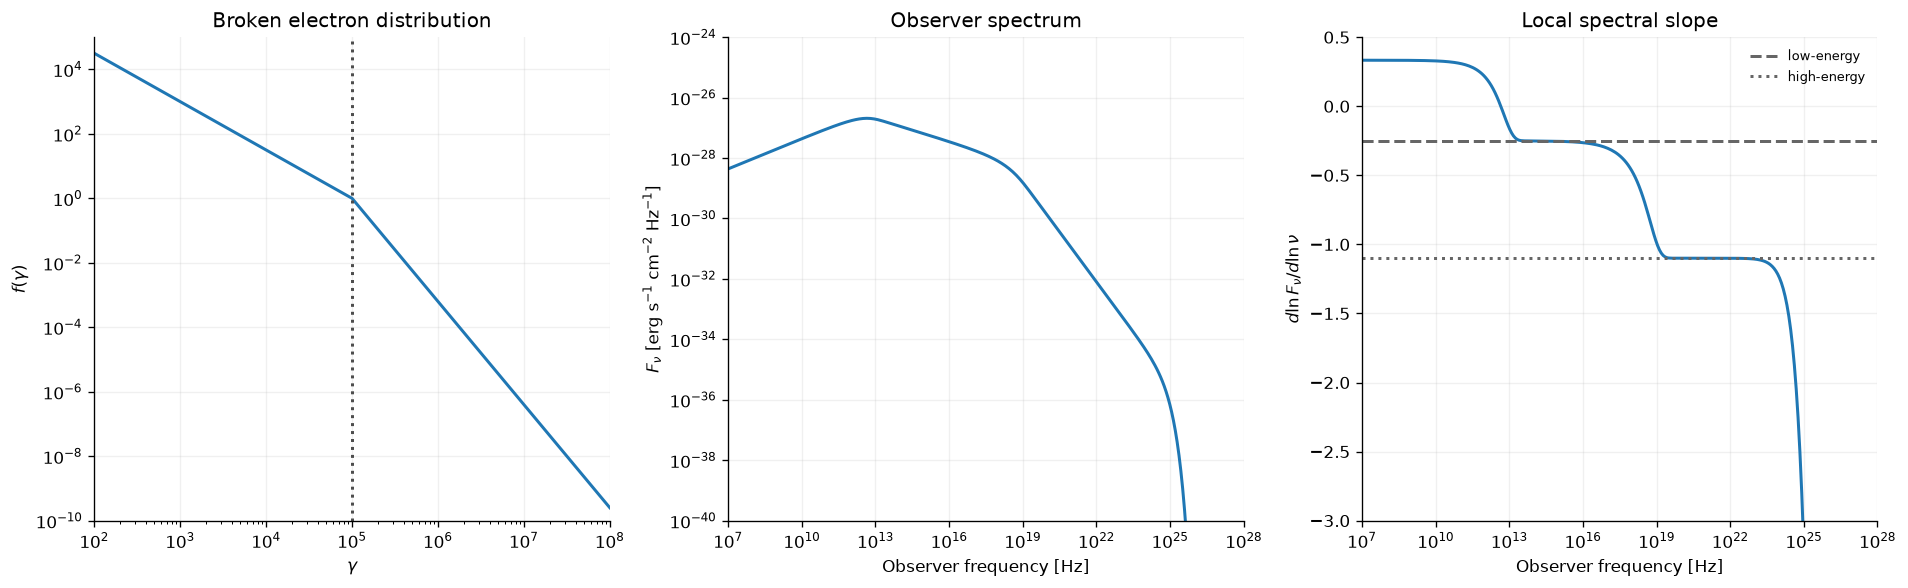

In [57]:
P1, P2, GAMMA_B = 1.5, 3.2, 1e5


def broken_powerlaw(gamma):
    x = gamma / GAMMA_B
    return np.where(gamma < GAMMA_B, x ** (-P1), x ** (-P2))


broken_e = custom_electrons(broken_powerlaw)
broken_flux = observer_spectrum(make_model(broken_e, ssa=False))
nu_local, broken_local_slope = local_log_slope(NU, broken_flux)

fig, axes = plt.subplots(1, 3, figsize=TRIPLE_FIGSIZE)
plot_positive(axes[0], broken_e.gamma, broken_e.shape)
axes[0].axvline(GAMMA_B, color="0.3", ls=":")
axes[0].set(
    xlabel=r"$\gamma$",
    ylabel=r"$f(\gamma)$",
    title="Broken electron distribution",
    xlim=(1e2, 1e8),
    ylim=(1e-10, 1e5),
)

plot_positive(axes[1], NU, broken_flux)
spectrum_axes(
    axes[1],
    "Observer spectrum",
    xlim=(1e7, 1e28),
    ylim=(1e-40, 1e-24),
)

axes[2].semilogx(nu_local, broken_local_slope)
axes[2].axhline(-(P1 - 1) / 2, color="0.4", ls="--", label="low-energy")
axes[2].axhline(-(P2 - 1) / 2, color="0.4", ls=":", label="high-energy")
axes[2].set(
    xlabel="Observer frequency [Hz]",
    ylabel=r"$d\ln F_\nu/d\ln\nu$",
    title="Local spectral slope",
    xlim=(1e7, 1e28),
    ylim=(-3.0, 0.5),
)
axes[2].legend(fontsize=8)
show_figure(fig, "07_broken_powerlaw")


### 7.2 Maxwell–Jüttner distribution

For dimensionless electron temperature $\Theta=kT/(m_e c^2)$, the relativistic thermal distribution in Lorentz factor is

$$
\frac{dN}{d\gamma}\propto \gamma^2\beta\,e^{-\gamma/\Theta},
\qquad
\beta=\sqrt{1-\gamma^{-2}}.
$$

This form is valid from non-relativistic to ultrarelativistic temperatures; the $\gamma$ grid must simply resolve the distribution for the chosen $\Theta$.


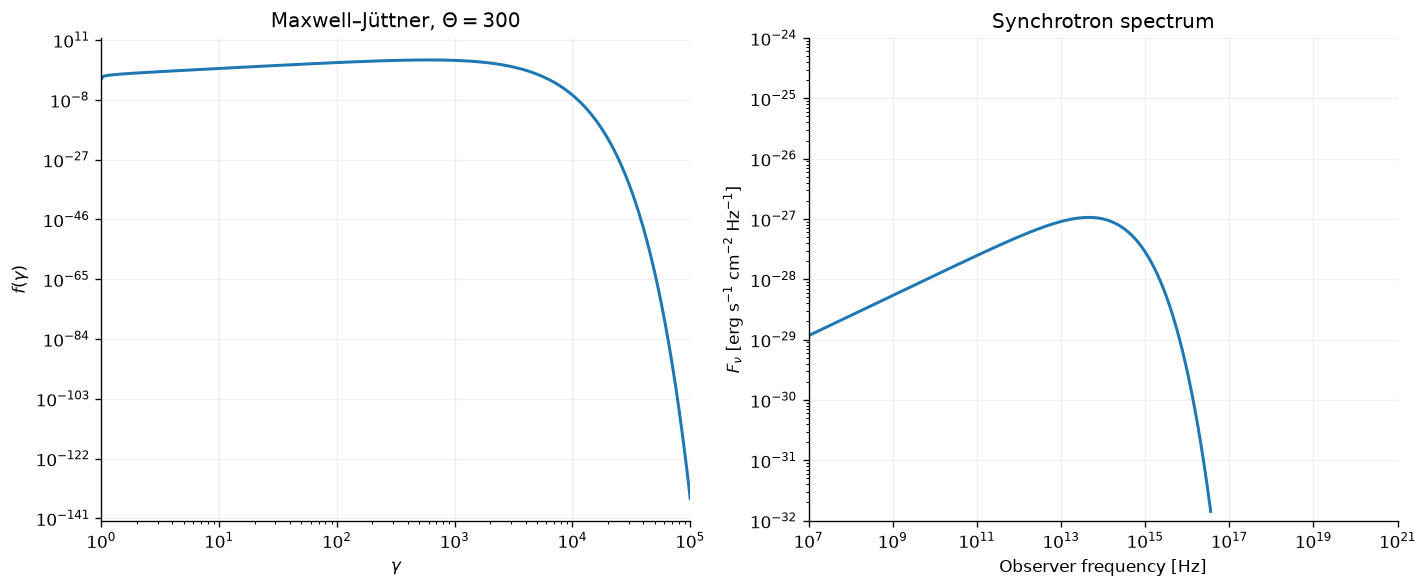

In [66]:
MAXWELL_THETA = 300.0
GAMMA_MIN_MJ = 1.001


def maxwell_juttner_shape(gamma, theta):
    gamma = np.asarray(gamma, dtype=float)
    beta = np.sqrt(np.maximum(1.0 - gamma**-2, 0.0))
    return gamma**2 * beta * np.exp(-gamma / theta)


def maxwellian_shape(gamma):
    return maxwell_juttner_shape(gamma, MAXWELL_THETA)


maxwellian_e = custom_electrons(
    maxwellian_shape,
    gamma_min=GAMMA_MIN_MJ,
    gamma_max=1e5,
    normalization="number",
)

maxwellian_flux = observer_spectrum(
    make_model(maxwellian_e, ssa=False)
)

flux_plot = np.where(
    maxwellian_flux >= 1e-32,
    maxwellian_flux,
    np.nan,
)

fig, axes = plt.subplots(1, 2, figsize=WIDE_FIGSIZE)

plot_positive(
    axes[0],
    maxwellian_e.gamma,
    maxwellian_e.shape,
)
axes[0].set(
    xlabel=r"$\gamma$",
    ylabel=r"$f(\gamma)$",
    title=rf"Maxwell–Jüttner, $\Theta={MAXWELL_THETA:g}$",
    xlim=(1, 1e5),
)

plot_positive(
    axes[1],
    NU,
    flux_plot,
)
spectrum_axes(
    axes[1],
    "Synchrotron spectrum",
    xlim=(1e7, 1e21),
    ylim=(1e-32, 1e-24),
)

show_figure(fig, "07_maxwell_juttner")

### 7.3 Thermal component plus nonthermal tail

This phenomenological example adds a power-law tail above $\gamma_{\rm tail}$. `TAIL_AMPLITUDE` is the tail amplitude relative to the thermal component at the join; it is **not** a prescribed number or energy fraction. The sharp join is used only for this illustration.


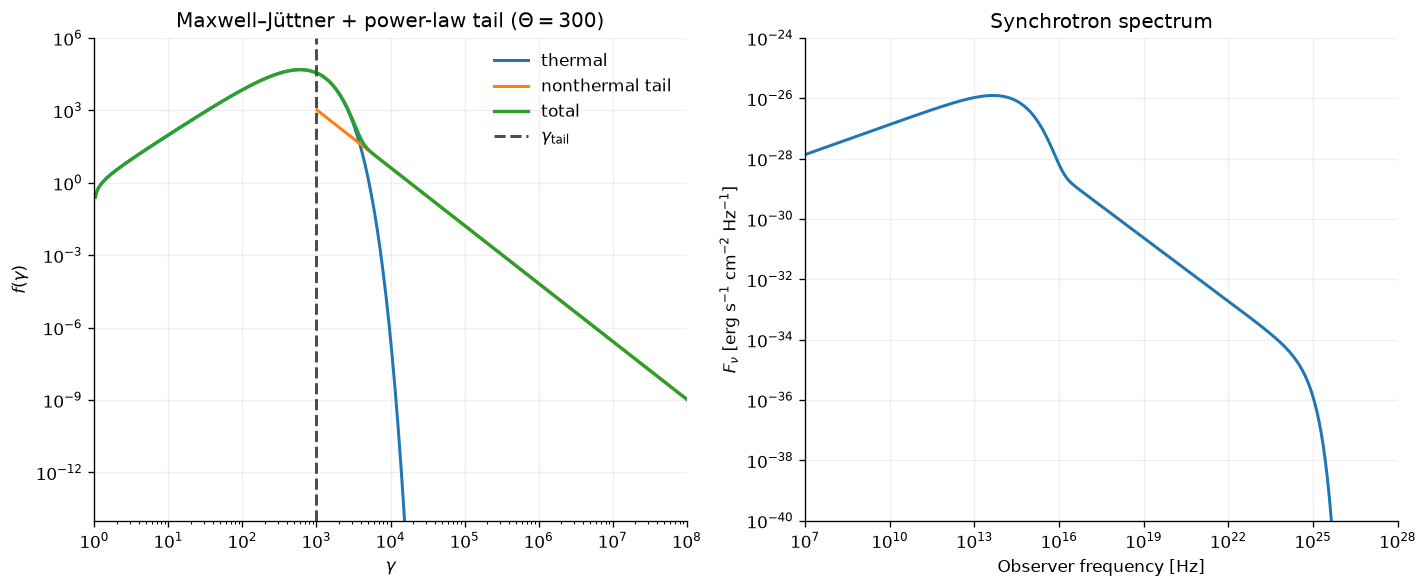

In [59]:
THERMAL_THETA = 300.0
TAIL_START = 1e3
TAIL_P = 2.4
TAIL_AMPLITUDE = 0.03


def thermal_component(gamma):
    return maxwell_juttner_shape(gamma, THERMAL_THETA)


def tail_component(gamma):
    gamma = np.asarray(gamma, dtype=float)
    tail_norm = TAIL_AMPLITUDE * thermal_component(TAIL_START)
    return np.where(
        gamma >= TAIL_START,
        tail_norm * (gamma / TAIL_START) ** (-TAIL_P),
        0.0,
    )


def thermal_plus_tail(gamma):
    return thermal_component(gamma) + tail_component(gamma)


thermal_tail_e = custom_electrons(
    thermal_plus_tail,
    gamma_min=1.0,
    gamma_max=1e8,
    samples=96,
)
thermal_tail_flux = observer_spectrum(make_model(thermal_tail_e, ssa=False))
gamma_plot = np.logspace(0, 8, 600)

fig, axes = plt.subplots(1, 2, figsize=WIDE_FIGSIZE)
plot_positive(axes[0], gamma_plot, thermal_component(gamma_plot), label="thermal")
plot_positive(axes[0], gamma_plot, tail_component(gamma_plot), label="nonthermal tail")
plot_positive(axes[0], gamma_plot, thermal_plus_tail(gamma_plot), lw=2, label="total")
axes[0].axvline(TAIL_START, ls="--", color="0.3", label=r"$\gamma_{\rm tail}$")
axes[0].set(
    xlabel=r"$\gamma$",
    ylabel=r"$f(\gamma)$",
    title=rf"Maxwell–Jüttner + power-law tail ($\Theta={THERMAL_THETA:g}$)",
    xlim=(1, 1e8),
    ylim=(1e-14, 1e6),
)
axes[0].legend()

plot_positive(axes[1], NU, thermal_tail_flux)
spectrum_axes(
    axes[1],
    "Synchrotron spectrum",
    xlim=(1e7, 1e28),
    ylim=(1e-40, 1e-24),
)
show_figure(fig, "07_thermal_plus_tail")


### 7.4 Pile-up distributions

Broad and narrow log-normal-like electron populations illustrate how the synchrotron kernel smooths localized structure. The narrower case uses denser electron sampling.


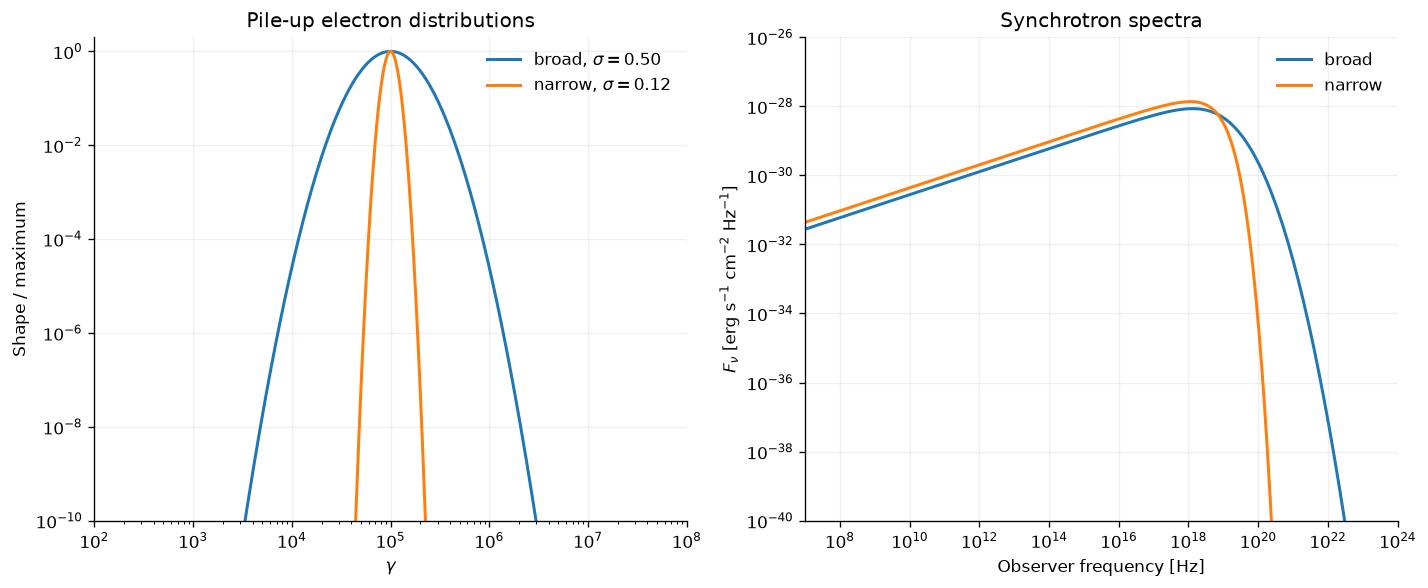

In [65]:
PILE_GAMMA0 = 1e5


def pile_broad_shape(gamma):
    return lognormal_shape(gamma, PILE_GAMMA0, 0.50)


def pile_narrow_shape(gamma):
    return lognormal_shape(gamma, PILE_GAMMA0, 0.12)


pile_broad_e = custom_electrons(
    pile_broad_shape,
)

pile_narrow_e = custom_electrons(
    pile_narrow_shape,
    samples=128,
)

pile_broad_flux = observer_spectrum(
    make_model(pile_broad_e, ssa=False)
)

pile_narrow_flux = observer_spectrum(
    make_model(pile_narrow_e, ssa=False)
)

fig, axes = plt.subplots(1, 2, figsize=WIDE_FIGSIZE)

for electrons, label in (
    (pile_broad_e, r"broad, $\sigma=0.50$"),
    (pile_narrow_e, r"narrow, $\sigma=0.12$"),
):
    plot_positive(
        axes[0],
        electrons.gamma,
        normalized_for_plot(electrons.shape),
        label=label,
    )

axes[0].set(
    xlabel=r"$\gamma$",
    ylabel="Shape / maximum",
    title="Pile-up electron distributions",
    xlim=(GAMMA_MIN, GAMMA_MAX),
    ylim=(1e-10, 2),
)
axes[0].legend()

for flux, label in (
    (pile_broad_flux, "broad"),
    (pile_narrow_flux, "narrow"),
):
    plot_positive(axes[1], NU, flux, label=label)

spectrum_axes(
    axes[1],
    "Synchrotron spectra",
    xlim=(1e7, 1e24),
    ylim=(1e-40, 1e-26),
)
axes[1].legend()

show_figure(fig, "07_pileup")

### 7.5 Internal gap

A distribution can contain a genuinely empty interval in $\gamma$. The corresponding photon-space feature is much smoother because each electron radiates over a broad range of frequencies.


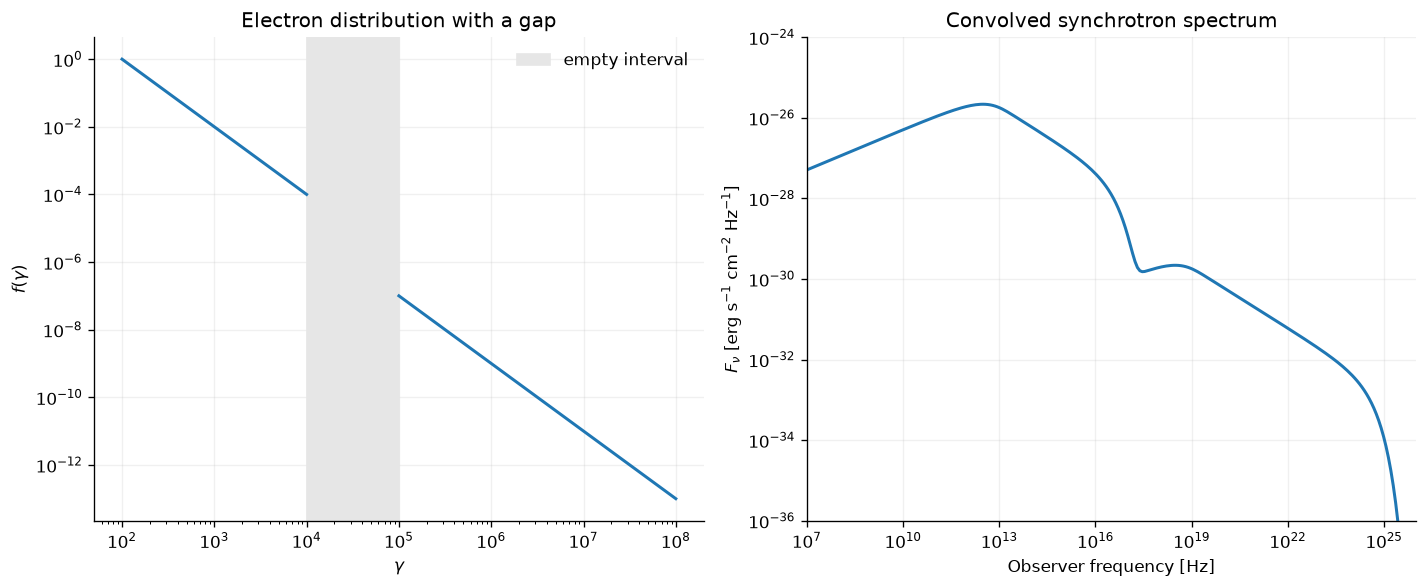

In [61]:
GAP1, GAP2 = 1e4, 1e5


def gapped_shape(gamma):
    base = (gamma / 1e2) ** (-2.0)
    return np.where(
        gamma < GAP1,
        base,
        np.where(gamma < GAP2, 0.0, 0.1 * base),
    )


gap_e = custom_electrons(gapped_shape, samples=128)
gap_flux = observer_spectrum(make_model(gap_e, ssa=False))

gamma_gap = np.asarray(gap_e.gamma)
shape_gap = np.asarray(gap_e.shape)

fig, axes = plt.subplots(1, 2, figsize=WIDE_FIGSIZE)
for support in (gamma_gap < GAP1, gamma_gap >= GAP2):
    plot_positive(axes[0], gamma_gap[support], shape_gap[support], color="C0")
axes[0].axvspan(GAP1, GAP2, color="0.9", label="empty interval")
axes[0].set(
    xlabel=r"$\gamma$",
    ylabel=r"$f(\gamma)$",
    title="Electron distribution with a gap",
)
axes[0].legend()

plot_positive(axes[1], NU, gap_flux)
spectrum_axes(
    axes[1],
    "Convolved synchrotron spectrum",
    xlim=(1e7, 1e26),
    ylim=(1e-36, 1e-24),
)
show_figure(fig, "07_internal_gap")


## 8. Forward and reverse shocks

The same numerical electron prescription can be attached to both shocks. Each shock normalizes the supplied shape using its own local fluid conditions.


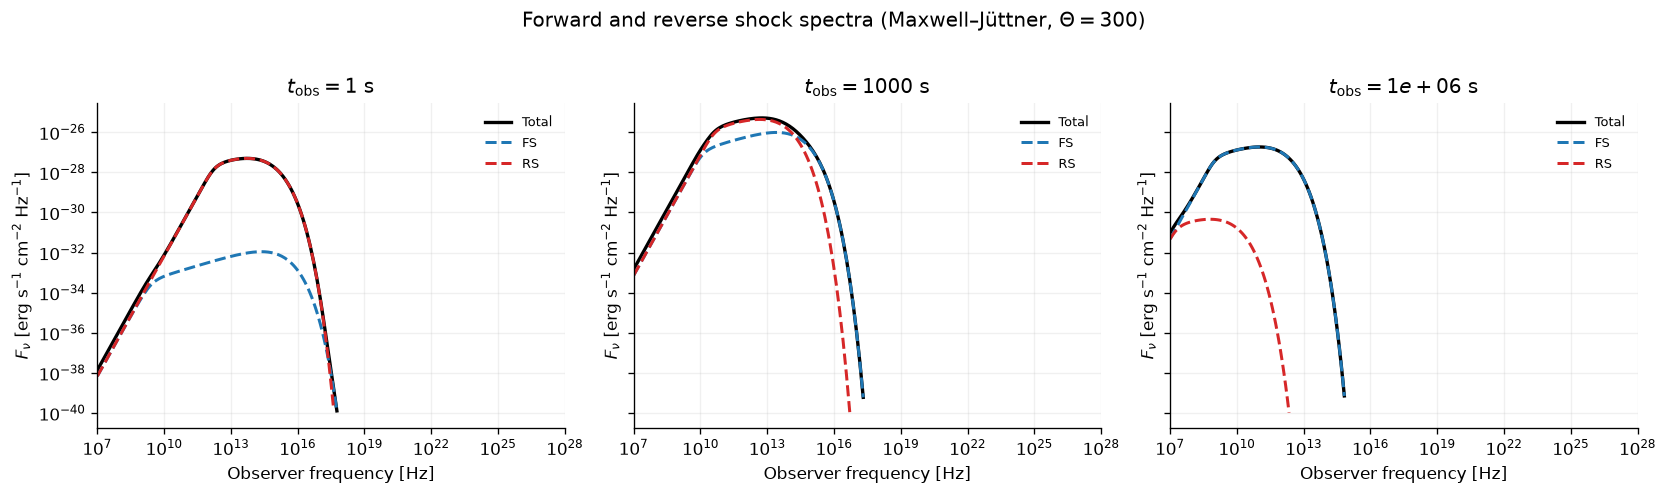

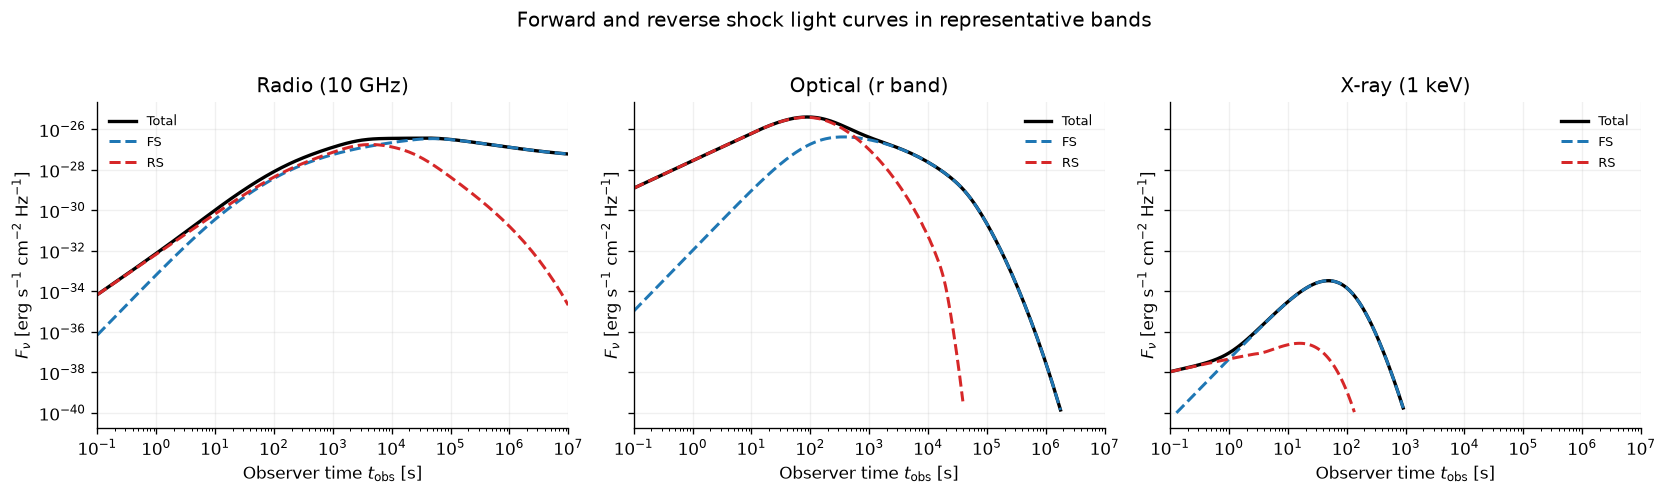

In [62]:
# ============================================================
# Forward + reverse shock: Maxwell–Jüttner spectra and light curves
# ============================================================

SPECTRUM_TIMES = np.array([1.0, 1e3, 1e6])

BANDS = {
    "Radio (10 GHz)": 1e10,
    "Optical (r band)": 4.8e14,
    "X-ray (1 keV)": 2.418e17,
}

LC_TIMES = np.logspace(-1, 7, 300)
THETA = 300.0

# Plotting floors: values below these are hidden
FLOOR_SPEC = 1e-40
FLOOR_LC = 1e-40


def maxwell_juttner_shape(gamma):
    gamma = np.asarray(gamma, dtype=float)
    beta = np.sqrt(np.maximum(1.0 - gamma**-2, 0.0))
    return gamma**2 * beta * np.exp(-gamma / THETA)


def masked_flux(y, floor):
    y = np.asarray(y, dtype=float)
    return np.where(np.isfinite(y) & (y >= floor), y, np.nan)


reverse_e = custom_electrons(
    maxwell_juttner_shape,
    gamma_min=1.0,
    gamma_max=1e8,
    normalization="number",
)

reverse_model = make_model(
    reverse_e,
    ssa=True,
    reverse=True,
    eps_B=1e-2,
    n_ism=1,
)

# ------------------------------------------------------------
# Spectra at selected observer times
# ------------------------------------------------------------

spectrum_result = reverse_model.flux_density_grid(
    SPECTRUM_TIMES,
    NU,
)

fig_spec, axes_spec = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, i, t_obs in zip(axes_spec, range(len(SPECTRUM_TIMES)), SPECTRUM_TIMES):
    fwd = np.asarray(spectrum_result.fwd.sync)[:, i]
    rvs = np.asarray(spectrum_result.rvs.sync)[:, i]
    total = fwd + rvs

    plot_positive(ax, NU, masked_flux(total, FLOOR_SPEC), color="k", lw=2, label="Total")
    plot_positive(ax, NU, masked_flux(fwd, FLOOR_SPEC), color="C0", ls="--", label="FS")
    plot_positive(ax, NU, masked_flux(rvs, FLOOR_SPEC), color="C3", ls="--", label="RS")

    spectrum_axes(
        ax,
        rf"$t_{{\rm obs}}={t_obs:g}$ s",
    )
    ax.set_xlim(1e7, 1e28)
    ax.legend(fontsize=8)

fig_spec.suptitle(
    rf"Forward and reverse shock spectra (Maxwell–Jüttner, $\Theta={THETA:g}$)",
    y=1.02,
)
fig_spec.tight_layout(rect=[0, 0, 1, 0.96])

show_figure(fig_spec, "08_forward_reverse_spectra")


# ------------------------------------------------------------
# Light curves in selected observer bands
# ------------------------------------------------------------

band_freqs = np.array(list(BANDS.values()))

lc_result = reverse_model.flux_density_grid(
    LC_TIMES,
    band_freqs,
)

fig_lc, axes_lc = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, j, (band, freq) in zip(axes_lc, range(len(BANDS)), BANDS.items()):
    fwd = np.asarray(lc_result.fwd.sync)[j, :]
    rvs = np.asarray(lc_result.rvs.sync)[j, :]
    total = fwd + rvs

    plot_positive(ax, LC_TIMES, masked_flux(total, FLOOR_LC), color="k", lw=2, label="Total")
    plot_positive(ax, LC_TIMES, masked_flux(fwd, FLOOR_LC), color="C0", ls="--", label="FS")
    plot_positive(ax, LC_TIMES, masked_flux(rvs, FLOOR_LC), color="C3", ls="--", label="RS")

    ax.set(
        xlabel=r"Observer time $t_{\rm obs}$ [s]",
        ylabel=r"$F_\nu$ [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]",
        title=band,
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(1e-1, 1e7)
    ax.legend(fontsize=8)

fig_lc.suptitle(
    "Forward and reverse shock light curves in representative bands",
    y=1.02,
)
fig_lc.tight_layout(rect=[0, 0, 1, 0.96])

show_figure(fig_lc, "08_forward_reverse_lightcurves")

## 9. Scope and takeaways

The notebook validates the full-kernel synchrotron implementation against the standard GS02 treatment, checks SSA implementation, and demonstrates built-in and arbitrary electron shapes in both forward and reverse shocks.

The numerical treatment is a more direct realization of a supplied $dN/d\gamma$, so detailed curvature near spectral features need not match a fitted broken-power-law photon spectrum even when the asymptotic physics agrees. For arbitrary distributions, standard break quantities such as $\gamma_m$, $\gamma_c$, $\nu_m$, and $\nu_c$ may simply be undefined.

These examples prescribe **instantaneous** electron shapes. They do not attach an independent kinetic history to every evolving afterglow cell; arbitrary-electron SSC and Klein–Nishina cooling are outside the scope of this notebook.
